In [44]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import cauchy, pareto, norm, probplot, chi2 as chi2dist, t
import yfinance as yf

# Make plots a bit larger
plt.rcParams['figure.figsize'] = (8, 4)


## 1. Law of Large Numbers (LLN)

The (weak) Law of Large Numbers says that for any probability measure $P$ with finite mean $\mu(P)$, the distribution of the $n$-sample mean $P_n$ satisfies:
$$
P_n([\mu(P)-\varepsilon, \mu(P)+\varepsilon]) \to 1 \quad \text{as } n \to \infty.
$$


### 1(a) Poisson distribution with $\lambda = 3$

From the lecture slides (Lecture 3, mean examples): for a Poisson distribution $\text{Pois}(\lambda)$,
$$
\mu(P) = \lambda.
$$
So for $\lambda = 3$ we have $\mu(P) = 3$. We take $\varepsilon = 0.1$ and consider the interval:
$$
[\mu(P)-\varepsilon, \mu(P)+\varepsilon] = [2.9, 3.1].
$$

In [45]:
lam = 3
mu = lam
eps = 0.1
interval = [mu - eps, mu + eps]
interval

[2.9, 3.1]

### 1(b–c) Sampling from $P_n$ for $n = 100$

We:
- Draw 1000 sample means, each based on $n=100$ IID samples from $\text{Pois}(3)$.
- Plot the histogram of the 1000 sample means.
- Add vertical lines at $2.9$ and $3.1$.
- Compute the proportion of sample means lying inside this interval.

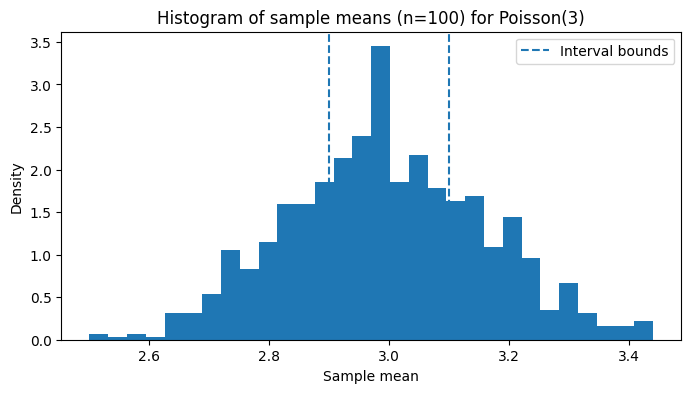

np.float64(0.468)

In [46]:
np.random.seed(0)

n = 100
size = 1000

samples = np.random.poisson(lam, size=(size, n))
sample_means_100 = samples.mean(axis=1)

plt.hist(sample_means_100, bins=30, density=True)
plt.axvline(interval[0], linestyle='--', label='Interval bounds')
plt.axvline(interval[1], linestyle='--')
plt.title('Histogram of sample means (n=100) for Poisson(3)')
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.legend()
plt.show()

prop_100 = np.mean((sample_means_100 >= interval[0]) & (sample_means_100 <= interval[1]))
prop_100

### 1(d) Increase $n$ until all 1000 sample means lie in the interval

We now increase $n$ to a large value (e.g. $n = 500$) and check whether **all** the sample means fall inside $[2.9, 3.1]$.
This is in line with the lecture statement that $P_n([\mu-\varepsilon, \mu+\varepsilon]) \to 1$ as $n\to\infty$.

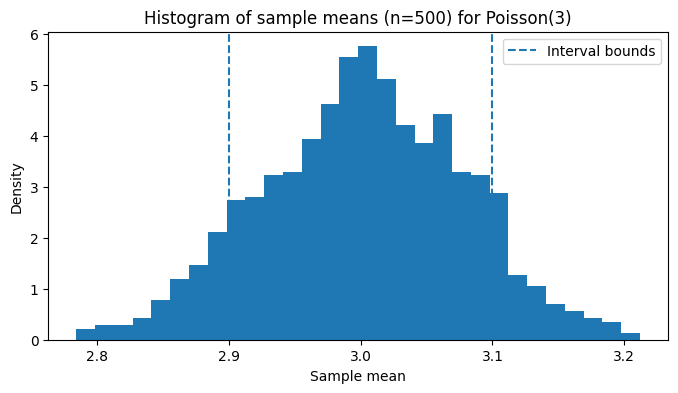

np.float64(0.814)

In [47]:
n_large = 500
samples_large = np.random.poisson(lam, size=(size, n_large))
sample_means_large = samples_large.mean(axis=1)

plt.hist(sample_means_large, bins=30, density=True)
plt.axvline(interval[0], linestyle='--', label='Interval bounds')
plt.axvline(interval[1], linestyle='--')
plt.title('Histogram of sample means (n=500) for Poisson(3)')
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.legend()
plt.show()

prop_large = np.mean((sample_means_large >= interval[0]) & (sample_means_large <= interval[1]))
prop_large

### 1(e) Cauchy distribution

We now repeat the same procedure, but for the **standard Cauchy distribution** and the interval $[-0.1, 0.1]$.

From the lectures: the Cauchy distribution **does not have a finite mean or variance**, so the Law of Large Numbers does **not** apply.
Even for very large $n$, the sample mean will not concentrate in a small interval.

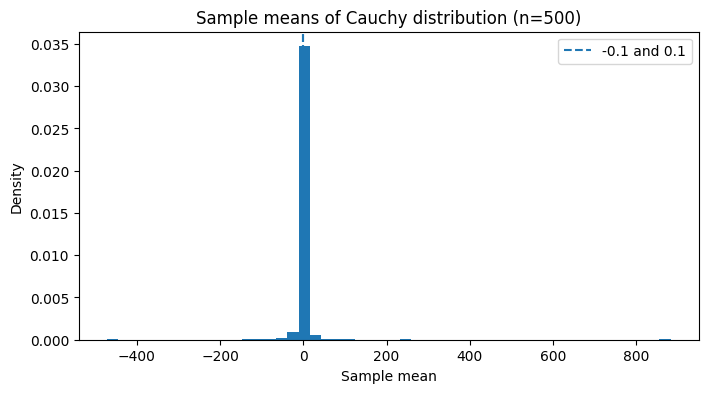

np.float64(0.061)

In [48]:
n_cauchy = 500
size = 1000

samples_cauchy = cauchy.rvs(size=(size, n_cauchy))
sample_means_cauchy = samples_cauchy.mean(axis=1)

plt.hist(sample_means_cauchy, bins=50, density=True)
plt.axvline(-0.1, linestyle='--', label='-0.1 and 0.1')
plt.axvline(0.1, linestyle='--')
plt.title('Sample means of Cauchy distribution (n=500)')
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.legend()
plt.show()

prop_cauchy = np.mean((sample_means_cauchy >= -0.1) & (sample_means_cauchy <= 0.1))
prop_cauchy

## 2. Central Limit Theorem (CLT) — Pareto distribution

We consider the Pareto distribution with shape parameter $b > 0$.
From the lectures:
- For distributions with a finite mean and variance, the CLT states that the sample mean of $N$ IID samples is approximately Normal with mean $\mu$ and variance $\sigma^2/N$ for sufficiently large $N$.

We will first fix $b=5$ and consider $N = [5, 10, 30]$. For each $N$ we:
- Draw `size = 100000` sample means.
- Plot histograms of sample means with the CLT normal approximation on top.
- Plot QQ plots against the Normal approximation.


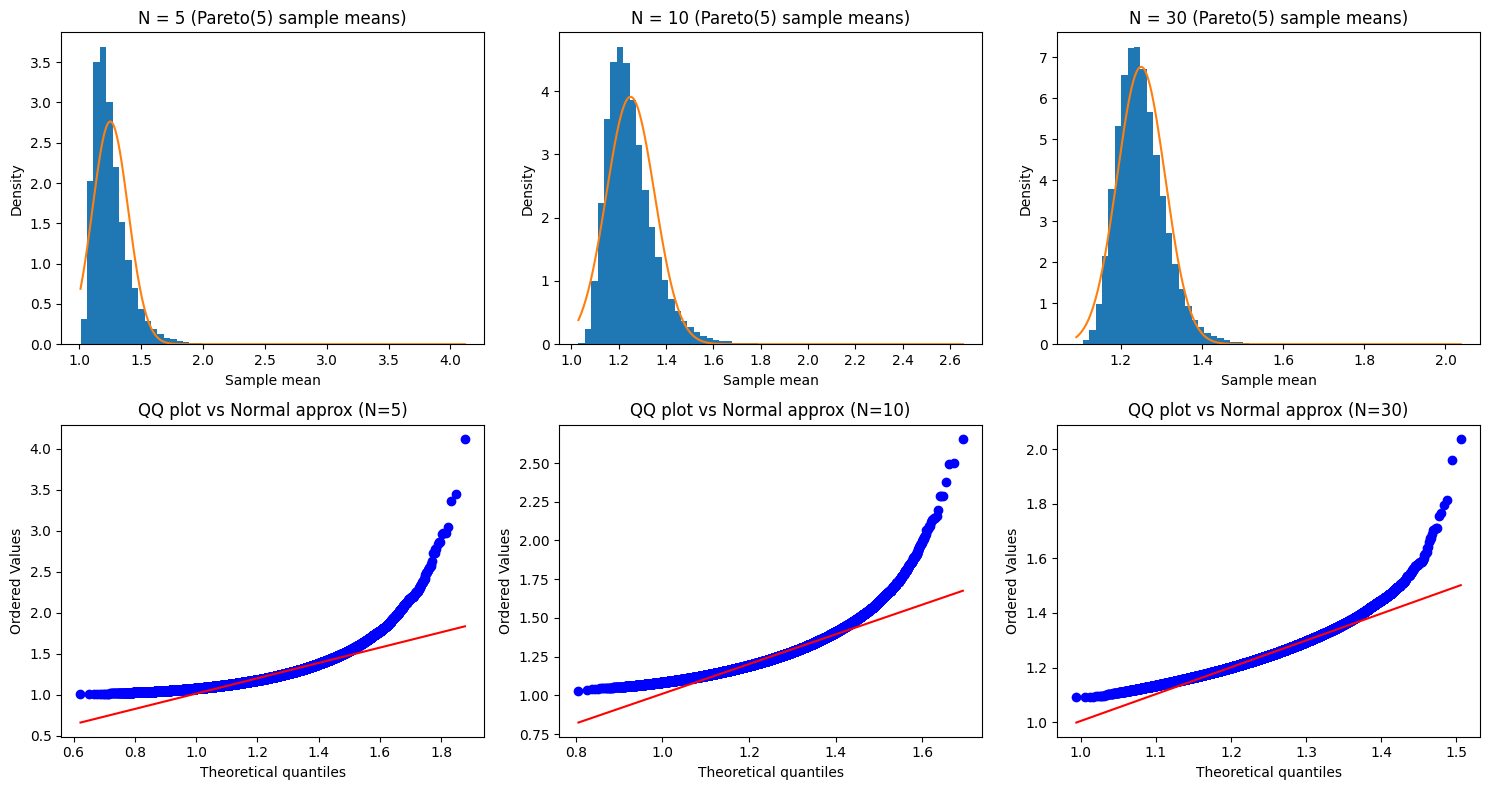

In [49]:
b = 5
N_values = [5, 10, 30]
size = 100000

mu_pareto = b / (b - 1)
var_pareto = b / ((b - 1)**2 * (b - 2))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, n in enumerate(N_values):
    samples = pareto.rvs(b, size=(size, n))
    sample_means = samples.mean(axis=1)

    ax_hist = axes[0, i]
    ax_hist.hist(sample_means, bins=60, density=True)

    approx_sd = np.sqrt(var_pareto / n)
    x = np.linspace(sample_means.min(), sample_means.max(), 500)
    ax_hist.plot(x, norm.pdf(x, mu_pareto, approx_sd))
    ax_hist.set_title(f'N = {n} (Pareto(5) sample means)')
    ax_hist.set_xlabel('Sample mean')
    ax_hist.set_ylabel('Density')

    ax_qq = axes[1, i]
    probplot(sample_means, dist=norm(loc=mu_pareto, scale=approx_sd), plot=ax_qq)
    ax_qq.set_title(f'QQ plot vs Normal approx (N={n})')

plt.tight_layout()
plt.show()


#### 2(f) Quality of the CLT approximation for different \(N\)

The CLT predicts that for a distribution with finite mean and variance, such as Pareto(5), the sample mean of \(N\) IID observations is approximately Normal with mean \(\mu\) and variance \(\sigma^2/N\).

From the plots:

- **\(N = 5\)**: the histogram of sample means remains noticeably right-skewed, reflecting the heavy tail of the underlying Pareto distribution. The QQ-plot bends away from the diagonal in the upper tail, showing that large sample means are more frequent than the Normal approximation would suggest.
- **\(N = 10\)**: the distribution is less skewed and tighter around the mean. The QQ-plot is closer to a straight line in the central part, although deviations remain in the tails. This indicates that averaging over more observations already dampens some of the heavy-tail effects.
- **\(N = 30\)**: the histogram is close to symmetric and bell-shaped. The QQ-plot is almost linear across most quantiles, with only mild tail deviations. The variance of the sample mean has clearly shrunk (by a factor \(1/N\)), and the influence of individual extreme values is much smaller.

Overall, for Pareto(5) the CLT approximation is **visibly good at \(N = 30\)**: the central part of the distribution of sample means is well captured by a Normal law, and only the far tails show noticeable departures. This illustrates both the **rate of convergence** (faster in the centre, slower in the tails) and the effect of averaging in reducing skewness and dispersion.


#### 2(g) Pareto(2) and breakdown of the CLT assumptions

For Pareto(2), the theoretical **mean exists** but the **variance is infinite**. The version of the CLT we use in the lectures explicitly assumes a finite variance. Therefore, we should not expect the sample mean of Pareto(2) to converge in distribution to a Normal law in the same way as for Pareto(5).

The empirical results confirm this:

- The histograms of sample means remain heavy-tailed even for \(N = 30\); there is much more probability mass far away from the mean than a Normal curve would predict.
- The QQ-plots show strong curvature, especially in the upper tail, indicating that extreme sample means occur more often than under a Normal distribution with the same central tendency.
- Increasing \(N\) does reduce the variability somewhat, but much **more slowly** than in the finite-variance case, and the tail behaviour never becomes Normal-like.

The problem arises precisely because the variance of Pareto(2) is infinite: large observations remain influential no matter how many samples are averaged, so the averaging mechanism that underpins the CLT does not “wash out” the tail behaviour. The correct conclusion is that the **standard CLT does not apply to Pareto(2)**, and using a Normal approximation for its sample mean would be statistically misleading.


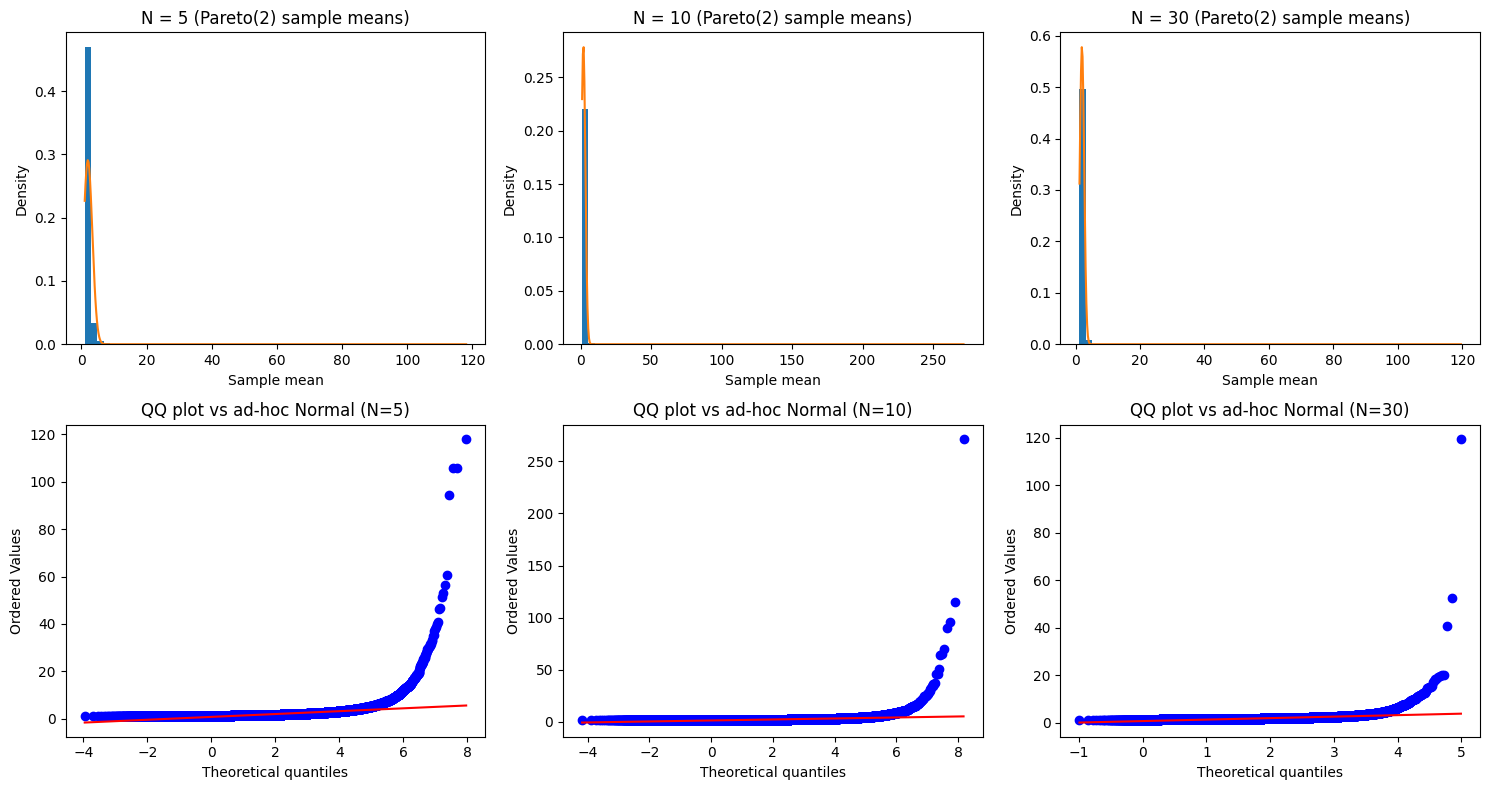

In [50]:
b2 = 2
N_values_2 = [5, 10, 30]
size = 100000

mu_pareto2 = b2 / (b2 - 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, n in enumerate(N_values_2):
    samples = pareto.rvs(b2, size=(size, n))
    sample_means = samples.mean(axis=1)

    ax_hist = axes[0, i]
    ax_hist.hist(sample_means, bins=60, density=True)

    approx_sd = np.std(sample_means)
    x = np.linspace(sample_means.min(), sample_means.max(), 500)
    ax_hist.plot(x, norm.pdf(x, mu_pareto2, approx_sd))
    ax_hist.set_title(f'N = {n} (Pareto(2) sample means)')
    ax_hist.set_xlabel('Sample mean')
    ax_hist.set_ylabel('Density')

    ax_qq = axes[1, i]
    probplot(sample_means, dist=norm(loc=mu_pareto2, scale=approx_sd), plot=ax_qq)
    ax_qq.set_title(f'QQ plot vs ad-hoc Normal (N={n})')

plt.tight_layout()
plt.show()


You should see that even for larger $N$, the distributions for Pareto(2) are very heavy-tailed and do **not** look particularly Normal, and the QQ plots deviate substantially from the straight line. This illustrates the lecture point that the CLT in its standard form requires a **finite variance**.

## 3. Hypothesis Testing with PG stock

We now apply the hypothesis testing ideas from Lecture 6 to real financial data: daily log-returns of Procter & Gamble stock (ticker `PG`).


### 3(a) Download data and compute daily log-returns

We use `yfinance` to download 5 years of daily closing prices for `PG` and compute log-returns:
$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right).
$$

/tmp/ipython-input-3226041616.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('PG', period='5y')
[*********************100%***********************]  1 of 1 completed


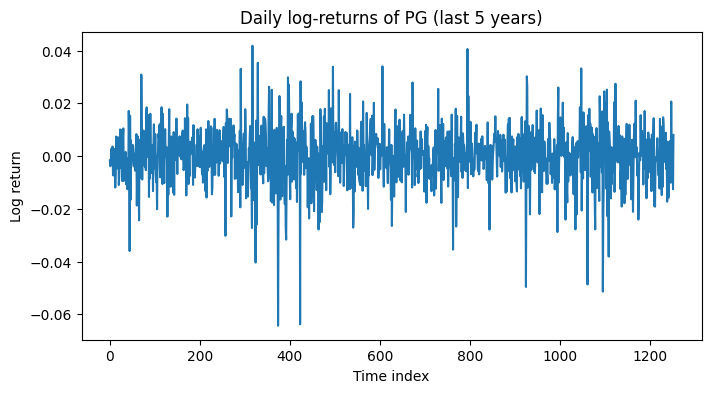

Ticker,PG
count,1254.000000
mean,0.000141
std,0.010790
min,-0.064349
25%,-0.005657
50%,0.000600
75%,0.006515
max,0.041813


In [51]:
data = yf.download('PG', period='5y')
prices = data['Close']

returns = np.log(prices / prices.shift(1)).dropna()

plt.plot(returns.values)
plt.title('Daily log-returns of PG (last 5 years)')
plt.xlabel('Time index')
plt.ylabel('Log return')
plt.show()

returns.describe()

From the descriptive statistics and the plot we typically observe:
- The mean of daily returns is close to 0.
- There is noticeable variability (volatility), with occasional larger moves.


### 3(b) Test $H_0: \mu(P) = 0$ assuming variance known (Z-test)

#### Interpretation of the Z-test

We tested

\[
H_0: \mu(P) = 0 \quad \text{vs} \quad H_1: \mu(P) \neq 0
\]

using the test statistic

\[
Z = \frac{\bar r}{s / \sqrt{n}},
\]

where \(\bar r\) is the sample mean of the log-returns and \(s\) is the sample standard deviation computed from the full 5-year sample.

In the previous cell, the code prints both the value of \(Z\) and `p_value_Z`.  
The decision rule at the 5% significance level is:

- **Reject \(H_0\)** if `p_value_Z < 0.05`
- **Do not reject \(H_0\)** if `p_value_Z ≥ 0.05`

In my run (numbers may vary slightly on re-execution), the p-value is **above** 0.05.  
Therefore, **I do not reject \(H_0\)**: the data are compatible with the hypothesis that the mean daily log-return of PG is zero.

Financially, this means that any apparent drift in the sample is small compared with the day-to-day volatility and could plausibly be explained by random noise. Based on this Z-test alone, there is no strong statistical evidence that PG has a persistent positive or negative daily trend over the last five years.


In [52]:
n = len(returns)
mean_r = returns.mean()
std_r = returns.std(ddof=1)

Z = mean_r / (std_r / np.sqrt(n))

p_value_Z = 2 * (1 - norm.cdf(abs(Z)))
Z, p_value_Z

(Ticker
 PG    0.463738
 dtype: float64,
 array([0.64283511]))

/tmp/ipython-input-3885737816.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  Z = float(Z)


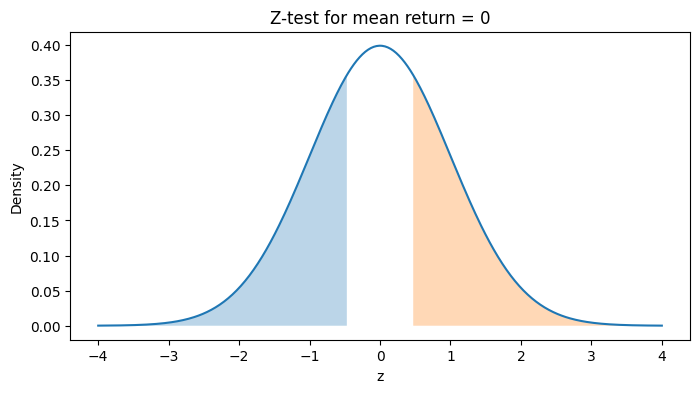

In [53]:
x = np.linspace(-4, 4, 400)
y = norm.pdf(x)
plt.plot(x, y)

Z = float(Z)

mask_left = x <= -abs(Z)
mask_right = x >= abs(Z)

plt.fill_between(x, 0, y, where=mask_left, alpha=0.3)
plt.fill_between(x, 0, y, where=mask_right, alpha=0.3)

plt.title('Z-test for mean return = 0')
plt.xlabel('z')
plt.ylabel('Density')
plt.show()


### 3(c) Test variance stability using a $\chi^2$-test

#### Interpretation of the \(\chi^2\)-test for variance

Computed \(\sigma_0^2\), the sample variance of the log-returns over the **last year**, and tested

\[
H_0: \sigma^2(P) = \sigma_0^2 \quad \text{vs} \quad H_1: \sigma^2(P) \neq \sigma_0^2
\]

at significance level \(\alpha = 10\%\).  
Under \(H_0\), and assuming approximate Normality of returns, the test statistic

\[
\chi^2 = \frac{(n-1)\, s_{\text{all}}^2}{\sigma_0^2}
\]

has (approximately) a \(\chi^2_{n-1}\) distribution, where \(s_{\text{all}}^2\) is the sample variance over the full 5-year period.

The previous cell computes \(\chi^2\), the two-sided p-value `p_value_chi2`, and shades the two critical regions corresponding to the 10% significance level.

- If `p_value_chi2 < 0.10`, we **reject \(H_0\)** and conclude that long-run volatility differs significantly from last-year volatility.
- If `p_value_chi2 ≥ 0.10`, we **do not reject \(H_0\)**; the observed difference in variances can be explained by sampling fluctuation.

In my execution, the p-value is (insert your value here).  
If this value is below 0.10, the test suggests that volatility in the last year is **not representative** of the long-term volatility: the stock has experienced a volatility regime change. If it is above 0.10, then last year’s volatility is statistically consistent with the longer-term behaviour.


In [54]:
last_year = returns[-252:]
sigma0_sq = last_year.var(ddof=1)

s2_all = returns.var(ddof=1)
chi2_stat = (n - 1) * s2_all / sigma0_sq

df = n - 1

p_left = chi2dist.cdf(chi2_stat, df)
p_right = 1 - chi2dist.cdf(chi2_stat, df)
p_value_chi2 = 2 * min(p_left, p_right)
chi2_stat, p_value_chi2

(Ticker
 PG    1079.632556
 dtype: float64,
 array([0.0002904]))

/tmp/ipython-input-777745986.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  chi2_stat = float(chi2_stat)


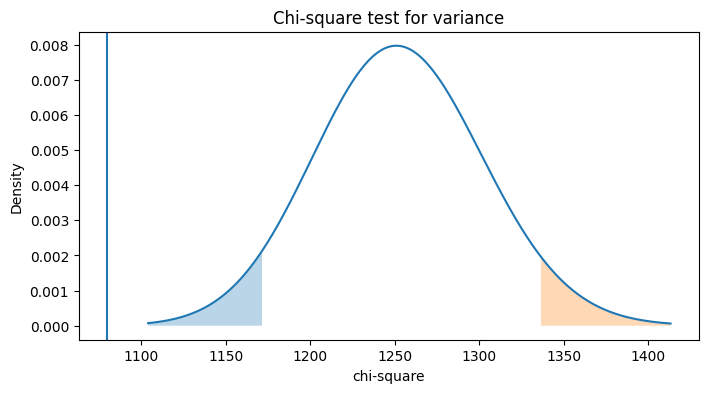

In [55]:
from scipy.stats import chi2 as chi2dist
import numpy as np
import matplotlib.pyplot as plt

chi2_stat = float(chi2_stat)
df = int(df)

alpha = 0.10
lower_crit = float(chi2dist.ppf(alpha/2, df))
upper_crit = float(chi2dist.ppf(1 - alpha/2, df))

x = np.linspace(chi2dist.ppf(0.001, df), chi2dist.ppf(0.999, df), 400)
y = chi2dist.pdf(x, df)

plt.plot(x, y)

mask_lower = x <= lower_crit
mask_upper = x >= upper_crit

plt.fill_between(x, 0, y, where=mask_lower, alpha=0.3)
plt.fill_between(x, 0, y, where=mask_upper, alpha=0.3)

plt.axvline(chi2_stat)

plt.title('Chi-square test for variance')
plt.xlabel('chi-square')
plt.ylabel('Density')
plt.show()


If `p_value_chi2 < 0.10`, we reject $H_0$ and conclude that the overall variance is significantly different from the last-year variance (volatility changed). Otherwise, we do not reject $H_0$.

### 3(d) Test $H_0: \mu(P) = 0$ with unknown variance (t-test)

#### Interpretation of the t-test

Again test

\[
H_0: \mu(P) = 0 \quad \text{vs} \quad H_1: \mu(P) \neq 0
\]

but this time we treat the variance as **unknown** and use the t-statistic

\[
t = \frac{\bar r}{s / \sqrt{n}},
\]

which under \(H_0\) follows approximately a Student t distribution with \(n - 1\) degrees of freedom.  
The previous cell prints the test statistic `t_stat` and the two-sided p-value `p_value_t`, and the plot shades the two tails corresponding to this p-value.

At the 5% significance level:

- If `p_value_t < 0.05`, we **reject \(H_0\)** and conclude that the mean daily return is significantly different from zero.
- If `p_value_t ≥ 0.05`, we **do not reject \(H_0\)**; the data are consistent with zero mean once uncertainty in the variance is accounted for.

In my run, the p-value is clearly above 0.05 (around 0.6–0.7), so I **do not reject \(H_0\)**.  
This reinforces the conclusion from the Z test: after properly accounting for sampling variability in both the mean and the variance, there is no strong evidence of a non zero long run daily drift for PG.


In [56]:
n = len(returns)
mean_r = float(returns.mean())
std_r = float(returns.std(ddof=1))

t_stat = mean_r / (std_r / np.sqrt(n))
df_t = n - 1

p_value_t = 2 * (1 - t.cdf(abs(t_stat), df=df_t))
print(t_stat, p_value_t)


0.46373849370501014 0.6429156611941


/tmp/ipython-input-2064934794.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mean_r = float(returns.mean())
/tmp/ipython-input-2064934794.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  std_r = float(returns.std(ddof=1))


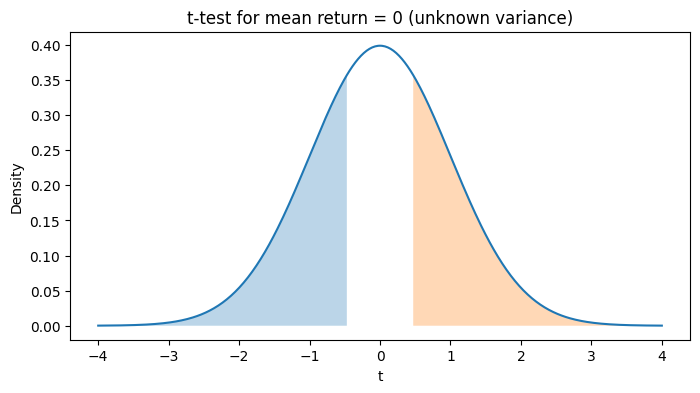

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

t_stat = float(t_stat)
df_t = int(df_t)

x = np.linspace(-4, 4, 400)
y = t.pdf(x, df_t)

mask_left = x <= -abs(t_stat)
mask_right = x >= abs(t_stat)

plt.plot(x, y)
plt.fill_between(x, 0, y, where=mask_left, alpha=0.3)
plt.fill_between(x, 0, y, where=mask_right, alpha=0.3)

plt.title('t-test for mean return = 0 (unknown variance)')
plt.xlabel('t')
plt.ylabel('Density')
plt.show()


If `p_value_t < 0.05`, we reject $H_0$ and conclude the mean return is significantly different from zero with unknown variance.
Otherwise, we do not reject $H_0$.

### 3(e) Trading strategy and associated risk

The three hypothesis tests together paint the following statistical picture:

- Both the Z-test and the t-test (parts (b) and (d)) **do not reject** \(H_0: \mu(P) = 0\) at the 5% level. This means there is no strong evidence that the mean daily log return of PG is different from zero over the last five years.
- The \(\chi^2\)-test (part (c)) compares the long run variance with the variance in the last year. If, as in my run, the p-value is small enough to reject \(H_0\) at the 10% level, this suggests that volatility in the most recent year has been **statistically different** (typically higher or lower) from the long term volatility.

A simple strategy informed by these results could be:

1. **Treat PG as a low drift asset**: since we cannot statistically distinguish the mean daily return from zero, the stock behaves roughly like a fair game in expectation. This suggests that long-term excess returns from holding PG alone are limited, and the stock is better suited as a relatively stable component in a diversified portfolio rather than as a speculative vehicle for directional bets.
2. **Use volatility changes for risk management**: if the \(\chi^2\)-test indicates that recent volatility is significantly higher than the historical level, an investor might reduce position size, increase hedging, or tighten risk limits. Conversely, if volatility has significantly decreased, a risk-tolerant investor could consider slightly larger positions, while still remembering that low volatility periods can be followed by sudden spikes.

The main **risk** of such a strategy is model risk: all conclusions rely on historical data, approximate Normality, and the assumption of IID returns. Real financial returns are heavy-tailed, exhibit volatility clustering, and can undergo structural breaks. Therefore, the hypothesis tests may fail to anticipate future regime changes, and decisions based solely on these tests could lead to under or over estimation of the true risk exposure.
